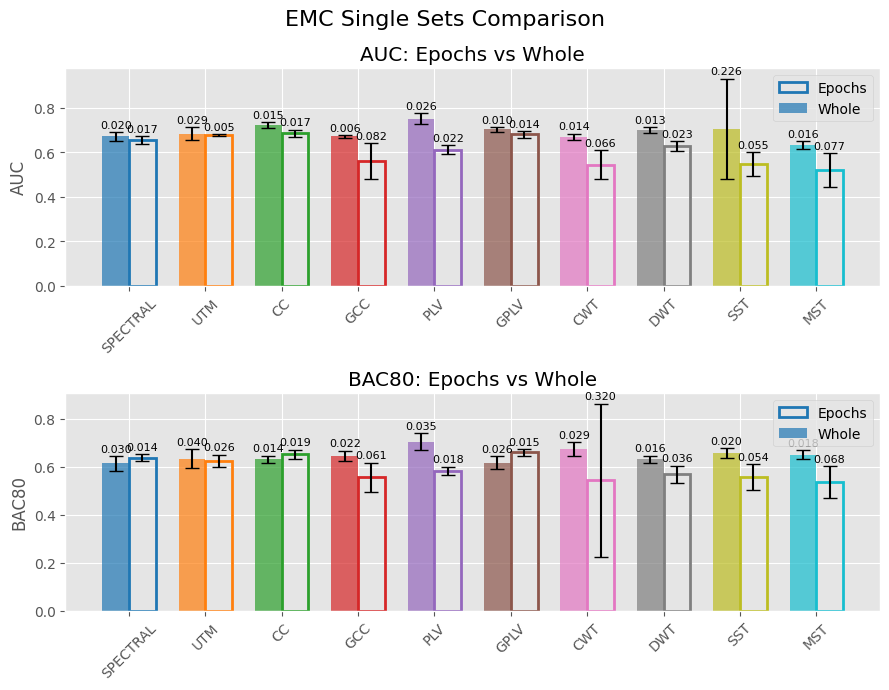

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#use ggplot style
plt.style.use('ggplot')


colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)
# TUH DATA SINGLE SET EPOCHED VERSION
data_epochs = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.65386, "AUC_STD": 0.017399, "BAC80": 0.63814, "BAC80_STD": 0.014028},
    {"FEATURE_SET": "UTM",      "AUC": 0.67649, "AUC_STD": 0.0051417, "BAC80": 0.62527, "BAC80_STD": 0.025616},
    {"FEATURE_SET": "CC",       "AUC": 0.68411, "AUC_STD": 0.017056, "BAC80": 0.65248, "BAC80_STD": 0.018523},
    {"FEATURE_SET": "GCC",      "AUC": 0.55916, "AUC_STD": 0.081619, "BAC80": 0.55597, "BAC80_STD": 0.061429},
    {"FEATURE_SET": "PLV",      "AUC": 0.61139, "AUC_STD": 0.021653, "BAC80": 0.58317, "BAC80_STD": 0.018149},
    {"FEATURE_SET": "GPLV",     "AUC": 0.67926, "AUC_STD": 0.014097, "BAC80": 0.6604,  "BAC80_STD": 0.014684},
    {"FEATURE_SET": "CWT",      "AUC": 0.54272, "AUC_STD": 0.065951, "BAC80": 0.54404, "BAC80_STD": 0.31994},
    {"FEATURE_SET": "DWT",      "AUC": 0.62772, "AUC_STD": 0.023093, "BAC80": 0.56931, "BAC80_STD": 0.036277},
    {"FEATURE_SET": "SST",      "AUC": 0.54619, "AUC_STD": 0.055236, "BAC80": 0.55597, "BAC80_STD": 0.054329},
    {"FEATURE_SET": "MST",      "AUC": 0.51797, "AUC_STD": 0.076943, "BAC80": 0.53621, "BAC80_STD": 0.067534},
]


data_whole = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.67084, "AUC_STD": 0.01954, "BAC80": 0.61485, "BAC80_STD": 0.030235},
    {"FEATURE_SET": "UTM",      "AUC": 0.68262, "AUC_STD": 0.02942, "BAC80": 0.63465, "BAC80_STD": 0.039851},
    {"FEATURE_SET": "CC",       "AUC": 0.72094, "AUC_STD": 0.01458, "BAC80": 0.63267, "BAC80_STD": 0.014433},
    {"FEATURE_SET": "GCC",      "AUC": 0.67074, "AUC_STD": 0.00607, "BAC80": 0.64653, "BAC80_STD": 0.021692},
    {"FEATURE_SET": "PLV",      "AUC": 0.7501,  "AUC_STD": 0.02589, "BAC80": 0.70495, "BAC80_STD": 0.035284},
    {"FEATURE_SET": "GPLV",     "AUC": 0.70178, "AUC_STD": 0.01011, "BAC80": 0.61782, "BAC80_STD": 0.02603},
    {"FEATURE_SET": "CWT",      "AUC": 0.66941, "AUC_STD": 0.01412, "BAC80": 0.67379, "BAC80_STD": 0.029063},
    {"FEATURE_SET": "DWT",      "AUC": 0.69802, "AUC_STD": 0.01261, "BAC80": 0.63168, "BAC80_STD": 0.015811},
    {"FEATURE_SET": "SST",      "AUC": 0.70426, "AUC_STD": 0.22577, "BAC80": 0.65696, "BAC80_STD": 0.019799},
    {"FEATURE_SET": "MST",      "AUC": 0.63188, "AUC_STD": 0.01589, "BAC80": 0.65149, "BAC80_STD": 0.017642},
]

df_epochs = pd.DataFrame(data_epochs)
df_whole = pd.DataFrame(data_whole)

# Set up grouped bar plot parameters
x = np.arange(len(df_epochs))
width = 0.35

# Plotting AUC comparison
plt.figure(figsize=(9, 7))
plt.subplot(211)
plt.suptitle('EMC Single Sets Comparison', fontsize=16)

bars1 = plt.bar(x + width/2, df_epochs["AUC"], width, yerr=df_epochs["AUC_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole["AUC"], width, yerr=df_whole["AUC_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=0.7, label='Whole')

plt.ylabel("AUC")
plt.title("AUC: Epochs vs Whole")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", #±
             ha='center', va='bottom', fontsize=8)

# Plotting BAC80 comparison
plt.subplot(212)
bars1 = plt.bar(x + width/2, df_epochs["BAC80"], width, yerr=df_epochs["BAC80_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole["BAC80"], width, yerr=df_whole["BAC80_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=0.7, label='Whole')

plt.ylabel("BAC80")
plt.title("BAC80: Epochs vs Whole")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()